In [21]:
import random
import numpy as np

In [22]:
### 1. Von Neumann PRNG (Generalized)
def von_neumann_generator(seed, num_digits, total_samples):
    if num_digits % 2 != 0:
        raise ValueError("num_digits must be even.")

    results = []
    current_seed = int(str(seed).zfill(num_digits))

    while len(results) < total_samples:
        seen_states = set()
        while len(results) < total_samples:
            seed_str = str(current_seed).zfill(num_digits)

            if seed_str in seen_states:
                break  # Cycle detected, reseed
            seen_states.add(seed_str)

            squared = current_seed ** 2
            squared_str = str(squared).zfill(2 * num_digits)
            mid_start = (len(squared_str) - num_digits) // 2
            next_val = int(squared_str[mid_start:mid_start + num_digits])

            results.append(next_val)
            if next_val == 0:
                break  # Degeneration

            current_seed = next_val

        # Reseed
        current_seed = random.randint(10**(num_digits - 1), 10**num_digits - 1)

    return results[:total_samples]


### 2. Linear Congruential Generator (LCG)
def lcg_generator(seed, a, c, m, num_samples):
    current_x = seed
    results = []
    for _ in range(num_samples):
        current_x = (a * current_x + c) % m
        results.append(current_x)
    return results


### 3. Custom LCG + XOR-Shift
class CustomLCGXORShift:
    def __init__(self, seed, a=1664525, c=1013904223, m=2**32):
        self.state = seed % m
        self.a = a
        self.c = c
        self.m = m
        self.counter = 0

    def xorshift(self, x):
        # A simple XOR shift routine (not optimal but distinct)
        x ^= (x << 13) & 0xFFFFFFFF
        x ^= (x >> 17)
        x ^= (x << 5) & 0xFFFFFFFF
        return x & 0xFFFFFFFF

    def next(self):
        # Step 1: LCG
        lcg_out = (self.a * self.state + self.c) % self.m
        # Step 2: XOR-Shift
        xor_out = self.xorshift(lcg_out)
        # Step 3: Add counter to introduce variability
        self.counter = (self.counter + 1) % self.m
        final_out = (xor_out + self.counter) % self.m

        # Update state
        self.state = final_out
        return final_out

    def generate_sequence(self, num_samples):
        return [self.next() for _ in range(num_samples)]


# === Generate sequences === #
NUM_SAMPLES = 10000
SEED = 12345
A, C, M = 1664525, 1013904223, 2**32

lcg_seq = lcg_generator(SEED, A, C, M, NUM_SAMPLES)
vn_seq = von_neumann_generator(seed=SEED, num_digits=6, total_samples=NUM_SAMPLES)
custom_prng = CustomLCGXORShift(SEED, A, C, M)
custom_seq = custom_prng.generate_sequence(NUM_SAMPLES)

# Normalize all sequences to [0, 1] for fair comparison
def normalize(seq):
    arr = np.array(seq, dtype=np.float64)
    return (arr - arr.min()) / (arr.max() - arr.min())

lcg_norm = normalize(lcg_seq)
vn_norm = normalize(vn_seq)
custom_norm = normalize(custom_seq)

Running Monte Carlo for LCG with params1...
  Last Pi estimate: 3.143680 using 25000 points.
Running Monte Carlo for LCG with params2...
  Last Pi estimate: 3.333440 using 25000 points.
Running Monte Carlo for Von Neumann with params1...
  Last Pi estimate: 0.008960 using 25000 points.
Running Monte Carlo for Von Neumann with params2...
  Last Pi estimate: 0.000480 using 25000 points.
Running Monte Carlo for Custom LCG+XOR-Shift with params1...
  Last Pi estimate: 3.151840 using 25000 points.
Running Monte Carlo for Custom LCG+XOR-Shift with params2...
  Last Pi estimate: 3.089120 using 25000 points.


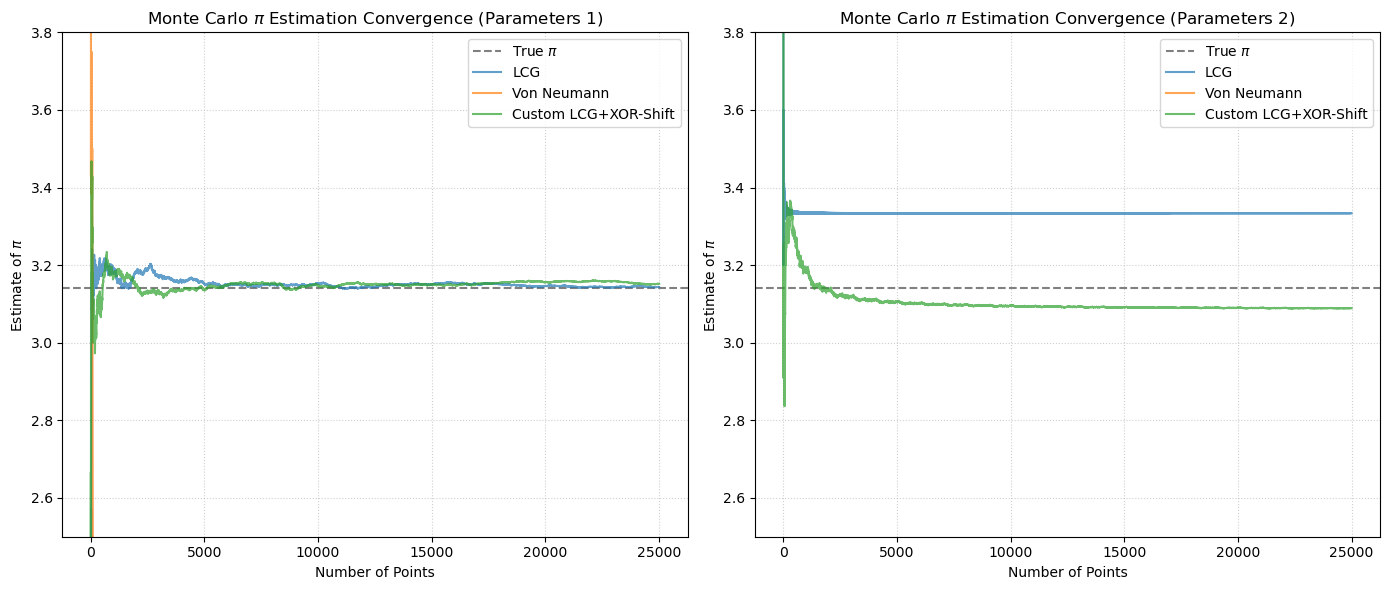

In [23]:
import random
import numpy as np
import matplotlib.pyplot as plt

# --- Provided PRNGs (copied for completeness) ---

### 1. Von Neumann PRNG (Generalized)
def von_neumann_generator(seed, num_digits, total_samples):
    if num_digits % 2 != 0:
        raise ValueError("num_digits must be even.")

    results = []
    current_seed = int(str(seed).zfill(num_digits))

    # To avoid immediate degeneration for very small seeds that would
    # otherwise lead to 0 quickly and stall the generator.
    # In a real application, you'd handle this more robustly or choose seeds carefully.
    if current_seed == 0 and num_digits > 0:
        current_seed = random.randint(10**(num_digits - 1), 10**num_digits - 1)

    samples_generated = 0
    while samples_generated < total_samples:
        seen_states = set()
        
        # Inner loop to generate numbers until cycle/degeneration or total samples met
        while samples_generated < total_samples:
            seed_str = str(current_seed).zfill(num_digits)

            if seed_str in seen_states:
                # Cycle detected, break from inner loop to reseed
                break
            seen_states.add(seed_str)

            squared = current_seed ** 2
            squared_str = str(squared).zfill(2 * num_digits)
            mid_start = (len(squared_str) - num_digits) // 2
            
            # Ensure mid_start + num_digits does not exceed squared_str length
            # This can happen if squared_str is shorter than expected (e.g., small squares)
            if mid_start + num_digits > len(squared_str):
                # This indicates a potential issue with num_digits or seed leading to very small squares.
                # For robustness, we might pad or take fewer digits if it's consistently short.
                # For now, let's ensure it doesn't crash, potentially leading to 0 if digits are missing
                next_val_str = squared_str[mid_start:]
                next_val = int(next_val_str.ljust(num_digits, '0')) # Pad with zeros if too short
            else:
                next_val = int(squared_str[mid_start:mid_start + num_digits])

            results.append(next_val)
            samples_generated += 1

            if next_val == 0:
                # Degeneration to 0. All subsequent values will be 0.
                # Fill remaining samples with 0s.
                results.extend([0] * (total_samples - samples_generated))
                samples_generated = total_samples # Mark as done
                break
            
            current_seed = next_val

        # Reseed only if we haven't reached total_samples yet and a cycle was detected
        if samples_generated < total_samples:
            # Generate a new random seed. Ensure it has num_digits.
            # Avoid re-seeding with 0 if num_digits is greater than 1.
            if num_digits == 1:
                current_seed = random.randint(0, 9)
            else:
                current_seed = random.randint(10**(num_digits - 1), 10**num_digits - 1)

    return results[:total_samples]


### 2. Linear Congruential Generator (LCG)
def lcg_generator(seed, a, c, m, num_samples):
    current_x = seed
    results = []
    for _ in range(num_samples):
        current_x = (a * current_x + c) % m
        results.append(current_x)
    return results


### 3. Custom LCG + XOR-Shift
class CustomLCGXORShift:
    def __init__(self, seed, a=1664525, c=1013904223, m=2**32):
        self.state = seed % m
        self.a = a
        self.c = c
        self.m = m
        self.counter = 0

    def xorshift(self, x):
        # A simple XOR shift routine (not optimal but distinct)
        x = x & 0xFFFFFFFF # Ensure x is 32-bit for consistent shifts
        x ^= (x << 13) & 0xFFFFFFFF
        x ^= (x >> 17)
        x ^= (x << 5) & 0xFFFFFFFF
        return x & 0xFFFFFFFF

    def next(self):
        # Step 1: LCG
        lcg_out = (self.a * self.state + self.c) % self.m
        # Step 2: XOR-Shift
        xor_out = self.xorshift(lcg_out)
        # Step 3: Add counter to introduce variability
        self.counter = (self.counter + 1) % self.m
        final_out = (xor_out + self.counter) % self.m

        # Update state
        self.state = final_out
        return final_out

    def generate_sequence(self, num_samples):
        return [self.next() for _ in range(num_samples)]

# Normalize function (already provided)
def normalize(seq, min_val=None, max_val=None):
    arr = np.array(seq, dtype=np.float64)
    # If min_val/max_val are not provided, use the sequence's min/max
    if min_val is None:
        min_val = arr.min()
    if max_val is None:
        max_val = arr.max()
    
    # Avoid division by zero if all values are the same
    if max_val == min_val:
        return np.zeros_like(arr)
    return (arr - min_val) / (max_val - min_val)

# Monte Carlo Pi Estimation Function
def estimate_pi_monte_carlo(rng_function, num_samples, *rng_args, max_val=None):
    # Generate numbers. If it's a class-based RNG, instantiate and then generate.
    if isinstance(rng_function, type): # Check if it's a class
        rng_instance = rng_function(*rng_args)
        raw_numbers = rng_instance.generate_sequence(num_samples)
    else: # It's a function
        raw_numbers = rng_function(*rng_args, num_samples)

    # Determine normalization range.
    # For LCG and CustomLCGXORShift, max_val is M-1 or 2^32-1.
    # For Von Neumann, max_val is 10^num_digits - 1.
    if max_val is None:
        if rng_function == lcg_generator or isinstance(rng_function, CustomLCGXORShift):
            max_val = rng_args[-2] - 1 # M-1
        elif rng_function == von_neumann_generator:
            max_val = 10**rng_args[1] - 1 # 10^num_digits - 1
        else:
            # Fallback if no specific max_val or it's not a known PRNG type
            max_val = max(raw_numbers) # This might lead to different scaling if sequence is short

    # Normalize to [-1, 1) for x and y coordinates
    # For uniform distribution in [-1, 1), we can normalize to [0, 1) and then map.
    normalized_x_y = normalize(raw_numbers, min_val=0, max_val=max_val) * 2 - 1 # Map [0,1) to [-1, 1)

    # Split into x and y coordinates
    x_coords = normalized_x_y[::2]
    y_coords = normalized_x_y[1::2]

    # If odd number of samples, discard the last x or y to make pairs
    min_len = min(len(x_coords), len(y_coords))
    x_coords = x_coords[:min_len]
    y_coords = y_coords[:min_len]

    num_points = len(x_coords)
    points_in_circle = 0
    
    # Calculate pi estimates at each step to see convergence
    pi_estimates = []
    
    for i in range(num_points):
        distance_squared = x_coords[i]**2 + y_coords[i]**2
        if distance_squared <= 1:
            points_in_circle += 1
        
        # Calculate estimate after each point pair
        if i + 1 > 0: # Ensure no division by zero
            pi_estimate_current = 4 * points_in_circle / (i + 1)
            pi_estimates.append(pi_estimate_current)

    return pi_estimates, num_points

# --- Configuration for Monte Carlo Simulations ---
NUM_SIMULATION_POINTS = 50000 # Total points for pi estimation

# Parameters 1
SEED_1 = 12345
A_1, C_1, M_1 = 1664525, 1013904223, 2**32
VN_DIGITS_1 = 6 # Example: for seed 12345, 6 digits could be appropriate.

# Parameters 2
SEED_2 = 54321
A_2, C_2, M_2 = 1341, 73, 1001 # Modulus 1001 = 7 * 11 * 13 (not a power of 2)
VN_DIGITS_2 = 2 # Small number of digits for simplicity, Von Neumann often degenerates quickly

prngs_and_params = {
    "LCG": {
        "params1": (lcg_generator, SEED_1, A_1, C_1, M_1, M_1 -1), # max_val is M-1
        "params2": (lcg_generator, SEED_2, A_2, C_2, M_2, M_2 -1),
    },
    "Von Neumann": {
        "params1": (von_neumann_generator, SEED_1, VN_DIGITS_1, 10**VN_DIGITS_1 -1), # max_val is 10^num_digits -1
        "params2": (von_neumann_generator, SEED_2, VN_DIGITS_2, 10**VN_DIGITS_2 -1),
    },
    "Custom LCG+XOR-Shift": {
        "params1": (CustomLCGXORShift, SEED_1, A_1, C_1, M_1, M_1 -1),
        "params2": (CustomLCGXORShift, SEED_2, A_2, C_2, M_2, M_2 -1),
    },
}

results_pi_estimation = {}

# Run simulations for each PRNG and parameter set
for prng_name, param_sets in prngs_and_params.items():
    results_pi_estimation[prng_name] = {}
    for param_set_name, args in param_sets.items():
        rng_func = args[0]
        rng_args = args[1:-1] # Pass all arguments except the max_val
        max_val_for_norm = args[-1]

        print(f"Running Monte Carlo for {prng_name} with {param_set_name}...")
        pi_estimates, num_points_used = estimate_pi_monte_carlo(rng_func, NUM_SIMULATION_POINTS, *rng_args, max_val=max_val_for_norm)
        results_pi_estimation[prng_name][param_set_name] = (pi_estimates, num_points_used)
        print(f"  Last Pi estimate: {pi_estimates[-1]:.6f} using {num_points_used} points.")


# --- Plotting the Convergence ---
plt.figure(figsize=(14, 6))

# Plot for Parameters 1
ax1 = plt.subplot(1, 2, 1)
ax1.axhline(np.pi, color='gray', linestyle='--', label='True $\\pi$')
for prng_name in prngs_and_params.keys():
    pi_estimates, num_points_used = results_pi_estimation[prng_name]["params1"]
    if pi_estimates: # Check if list is not empty
        x_axis = np.arange(1, len(pi_estimates) + 1)
        ax1.plot(x_axis, pi_estimates, label=prng_name, alpha=0.7)
ax1.set_title('Monte Carlo $\\pi$ Estimation Convergence (Parameters 1)')
ax1.set_xlabel('Number of Points')
ax1.set_ylabel('Estimate of $\\pi$')
ax1.set_ylim(2.5, 3.8) # Adjust y-limit for better visualization if needed
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.6)


# Plot for Parameters 2
ax2 = plt.subplot(1, 2, 2)
ax2.axhline(np.pi, color='gray', linestyle='--', label='True $\\pi$')
for prng_name in prngs_and_params.keys():
    pi_estimates, num_points_used = results_pi_estimation[prng_name]["params2"]
    if pi_estimates: # Check if list is not empty
        x_axis = np.arange(1, len(pi_estimates) + 1)
        ax2.plot(x_axis, pi_estimates, label=prng_name, alpha=0.7)
ax2.set_title('Monte Carlo $\\pi$ Estimation Convergence (Parameters 2)')
ax2.set_xlabel('Number of Points')
ax2.set_ylabel('Estimate of $\\pi$')
ax2.set_ylim(2.5, 3.8) # Adjust y-limit for better visualization if needed
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

Running Monte Carlo for Von Neumann with params1...
  Last Pi estimate: 0.008960 using 25000 points.
Running Monte Carlo for Von Neumann with params2...
  Last Pi estimate: 0.000480 using 25000 points.
Running Monte Carlo for LCG with params1...
  Last Pi estimate: 3.143680 using 25000 points.
Running Monte Carlo for LCG with params2...
  Last Pi estimate: 3.333440 using 25000 points.
Running Monte Carlo for Custom LCG+XOR-Shift with params1...
  Last Pi estimate: 3.151840 using 25000 points.
Running Monte Carlo for Custom LCG+XOR-Shift with params2...
  Last Pi estimate: 3.089120 using 25000 points.


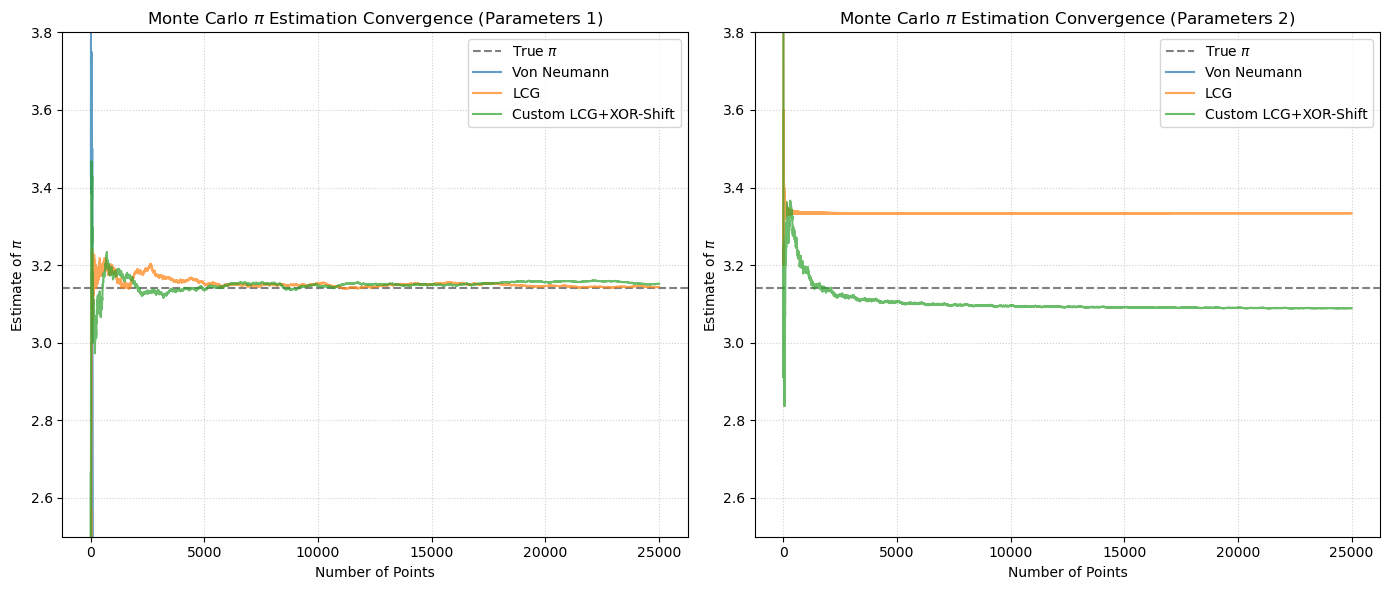

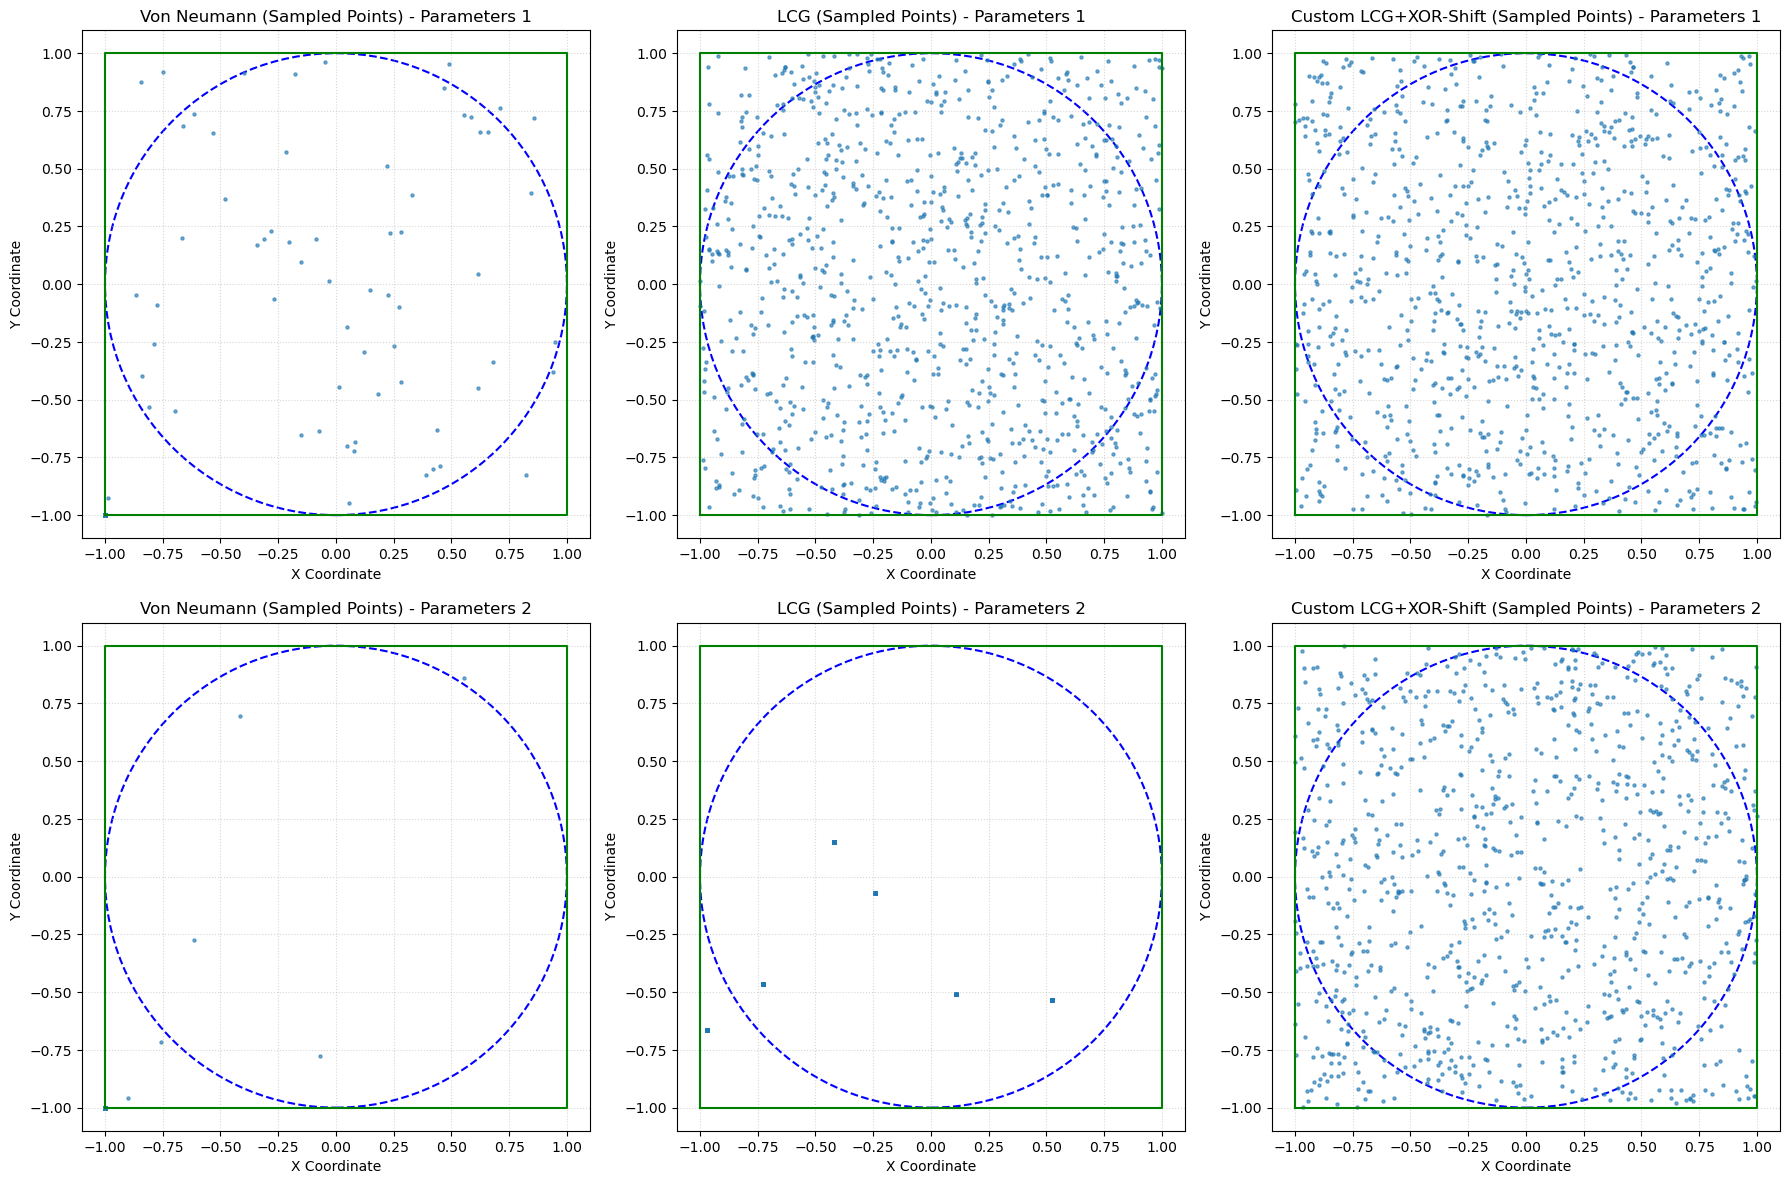

In [24]:
import random
import numpy as np
import matplotlib.pyplot as plt

# --- Provided PRNGs (copied for completeness) ---

### 1. Von Neumann PRNG (Generalized)
def von_neumann_generator(seed, num_digits, total_samples):
    if num_digits % 2 != 0:
        raise ValueError("num_digits must be even.")

    results = []
    current_seed = int(str(seed).zfill(num_digits))

    # To avoid immediate degeneration for very small seeds that would
    # otherwise lead to 0 quickly and stall the generator.
    if current_seed == 0 and num_digits > 0:
        current_seed = random.randint(10**(num_digits - 1), 10**num_digits - 1)

    samples_generated = 0
    while samples_generated < total_samples:
        seen_states = set()
        
        # Inner loop to generate numbers until cycle/degeneration or total samples met
        while samples_generated < total_samples:
            seed_str = str(current_seed).zfill(num_digits)

            if seed_str in seen_states:
                # Cycle detected, break from inner loop to reseed
                break
            seen_states.add(seed_str)

            squared = current_seed ** 2
            squared_str = str(squared).zfill(2 * num_digits)
            mid_start = (len(squared_str) - num_digits) // 2
            
            # Ensure mid_start + num_digits does not exceed squared_str length
            if mid_start + num_digits > len(squared_str):
                next_val_str = squared_str[mid_start:]
                next_val = int(next_val_str.ljust(num_digits, '0')) 
            else:
                next_val = int(squared_str[mid_start:mid_start + num_digits])

            results.append(next_val)
            samples_generated += 1

            if next_val == 0:
                results.extend([0] * (total_samples - samples_generated))
                samples_generated = total_samples 
                break
            
            current_seed = next_val

        # Reseed only if we haven't reached total_samples yet and a cycle was detected
        if samples_generated < total_samples:
            if num_digits == 1:
                current_seed = random.randint(0, 9)
            else:
                current_seed = random.randint(10**(num_digits - 1), 10**num_digits - 1)

    return results[:total_samples]


### 2. Linear Congruential Generator (LCG)
def lcg_generator(seed, a, c, m, num_samples):
    current_x = seed
    results = []
    for _ in range(num_samples):
        current_x = (a * current_x + c) % m
        results.append(current_x)
    return results


### 3. Custom LCG + XOR-Shift
class CustomLCGXORShift:
    def __init__(self, seed, a=1664525, c=1013904223, m=2**32):
        self.state = seed % m
        self.a = a
        self.c = c
        self.m = m
        self.counter = 0

    def xorshift(self, x):
        x = x & 0xFFFFFFFF
        x ^= (x << 13) & 0xFFFFFFFF
        x ^= (x >> 17)
        x ^= (x << 5) & 0xFFFFFFFF
        return x & 0xFFFFFFFF

    def next(self):
        lcg_out = (self.a * self.state + self.c) % self.m
        xor_out = self.xorshift(lcg_out)
        self.counter = (self.counter + 1) % self.m
        final_out = (xor_out + self.counter) % self.m
        self.state = final_out
        return final_out

    def generate_sequence(self, num_samples):
        return [self.next() for _ in range(num_samples)]

# Normalize function (already provided)
def normalize(seq, min_val=None, max_val=None):
    arr = np.array(seq, dtype=np.float64)
    if min_val is None:
        min_val = arr.min()
    if max_val is None:
        max_val = arr.max()
    
    if max_val == min_val:
        return np.zeros_like(arr)
    return (arr - min_val) / (max_val - min_val)

# Monte Carlo Pi Estimation Function (Modified to return raw normalized points as well)
def estimate_pi_monte_carlo(rng_function, num_samples, *rng_args, max_val=None):
    if isinstance(rng_function, type): 
        rng_instance = rng_function(*rng_args)
        raw_numbers = rng_instance.generate_sequence(num_samples)
    else: 
        raw_numbers = rng_function(*rng_args, num_samples)

    if max_val is None:
        if rng_function == lcg_generator or isinstance(rng_function, CustomLCGXORShift):
            max_val = rng_args[-2] - 1 
        elif rng_function == von_neumann_generator:
            max_val = 10**rng_args[1] - 1
        else:
            max_val = max(raw_numbers)

    normalized_x_y = normalize(raw_numbers, min_val=0, max_val=max_val) * 2 - 1 

    x_coords = normalized_x_y[::2]
    y_coords = normalized_x_y[1::2]

    min_len = min(len(x_coords), len(y_coords))
    x_coords = x_coords[:min_len]
    y_coords = y_coords[:min_len]

    num_points = len(x_coords)
    points_in_circle = 0
    
    pi_estimates = []
    
    for i in range(num_points):
        distance_squared = x_coords[i]**2 + y_coords[i]**2
        if distance_squared <= 1:
            points_in_circle += 1
        
        if i + 1 > 0:
            pi_estimate_current = 4 * points_in_circle / (i + 1)
            pi_estimates.append(pi_estimate_current)

    return pi_estimates, num_points, x_coords, y_coords # Return x and y coords

# --- Configuration for Monte Carlo Simulations ---
NUM_SIMULATION_POINTS = 50000 
NUM_POINTS_FOR_2D_PLOT = 1000 # Number of (x,y) pairs to plot for visualization

# Parameters 1
SEED_1 = 12345
A_1, C_1, M_1 = 1664525, 1013904223, 2**32
VN_DIGITS_1 = 6

# Parameters 2
SEED_2 = 54321
A_2, C_2, M_2 = 1341, 73, 1001 
VN_DIGITS_2 = 2

prngs_and_params = {
    "Von Neumann": {
        "params1": (von_neumann_generator, SEED_1, VN_DIGITS_1, 10**VN_DIGITS_1 -1), 
        "params2": (von_neumann_generator, SEED_2, VN_DIGITS_2, 10**VN_DIGITS_2 -1),
    },
    "LCG": {
        "params1": (lcg_generator, SEED_1, A_1, C_1, M_1, M_1 -1), 
        "params2": (lcg_generator, SEED_2, A_2, C_2, M_2, M_2 -1),
    },
    "Custom LCG+XOR-Shift": {
        "params1": (CustomLCGXORShift, SEED_1, A_1, C_1, M_1, M_1 -1),
        "params2": (CustomLCGXORShift, SEED_2, A_2, C_2, M_2, M_2 -1),
    },
}

results_pi_estimation = {}
raw_points_for_plot = {} # Store x, y coordinates for 2D plots

# Run simulations for each PRNG and parameter set
for prng_name, param_sets in prngs_and_params.items():
    results_pi_estimation[prng_name] = {}
    raw_points_for_plot[prng_name] = {}
    for param_set_name, args in param_sets.items():
        rng_func = args[0]
        rng_args = args[1:-1]
        max_val_for_norm = args[-1]

        print(f"Running Monte Carlo for {prng_name} with {param_set_name}...")
        pi_estimates, num_points_used, x_coords, y_coords = estimate_pi_monte_carlo(rng_func, NUM_SIMULATION_POINTS, *rng_args, max_val=max_val_for_norm)
        
        results_pi_estimation[prng_name][param_set_name] = (pi_estimates, num_points_used)
        
        # Store a subset of points for 2D visualization
        raw_points_for_plot[prng_name][param_set_name] = (x_coords[:NUM_POINTS_FOR_2D_PLOT], y_coords[:NUM_POINTS_FOR_2D_PLOT])
        
        print(f"  Last Pi estimate: {pi_estimates[-1]:.6f} using {num_points_used} points.")


# --- Plotting the Convergence (Existing Plot) ---
plt.figure(figsize=(14, 6))

# Plot for Parameters 1
ax1 = plt.subplot(1, 2, 1)
ax1.axhline(np.pi, color='gray', linestyle='--', label='True $\\pi$')
for prng_name in prngs_and_params.keys():
    pi_estimates, num_points_used = results_pi_estimation[prng_name]["params1"]
    if pi_estimates: 
        x_axis = np.arange(1, len(pi_estimates) + 1)
        ax1.plot(x_axis, pi_estimates, label=prng_name, alpha=0.7)
ax1.set_title('Monte Carlo $\\pi$ Estimation Convergence (Parameters 1)')
ax1.set_xlabel('Number of Points')
ax1.set_ylabel('Estimate of $\\pi$')
ax1.set_ylim(2.5, 3.8) 
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.6)


# Plot for Parameters 2
ax2 = plt.subplot(1, 2, 2)
ax2.axhline(np.pi, color='gray', linestyle='--', label='True $\\pi$')
for prng_name in prngs_and_params.keys():
    pi_estimates, num_points_used = results_pi_estimation[prng_name]["params2"]
    if pi_estimates: 
        x_axis = np.arange(1, len(pi_estimates) + 1)
        ax2.plot(x_axis, pi_estimates, label=prng_name, alpha=0.7)
ax2.set_title('Monte Carlo $\\pi$ Estimation Convergence (Parameters 2)')
ax2.set_xlabel('Number of Points')
ax2.set_ylabel('Estimate of $\\pi$')
ax2.set_ylim(2.5, 3.8) 
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


# --- New 2D Scatter Plots ---
# Create a figure with 2 rows and 3 columns for (3 PRNGs * 2 Parameter Sets)
fig_2d, axes_2d = plt.subplots(2, 3, figsize=(18, 12))
axes_2d = axes_2d.flatten() # Flatten for easier iteration

plot_idx = [0,3,1,4,2,5]
i = 0
for prng_name in prngs_and_params.keys():
    for param_set_name in ["params1", "params2"]:
        ax = axes_2d[plot_idx[i]]
        x_coords, y_coords = raw_points_for_plot[prng_name][param_set_name]

        # Plot the circle outline
        circle = plt.Circle((0, 0), 1, color='blue', fill=False, linestyle='--', linewidth=1.5)
        ax.add_patch(circle)

        # Plot the square boundaries
        ax.plot([-1, 1, 1, -1, -1], [-1, -1, 1, 1, -1], color='green', linestyle='-', linewidth=1.5)

        ax.scatter(x_coords, y_coords, s=5, alpha=0.6) # s is marker size
        ax.set_aspect('equal', adjustable='box')
        ax.set_xlim([-1.1, 1.1])
        ax.set_ylim([-1.1, 1.1])
        
        # Add a more descriptive title
        title = f"{prng_name} (Sampled Points) - {param_set_name.replace('params', 'Parameters ')}"
        ax.set_title(title)
        ax.set_xlabel('X Coordinate')
        ax.set_ylabel('Y Coordinate')
        ax.grid(True, linestyle=':', alpha=0.5)
        
        i+=1

plt.tight_layout()
plt.show()